# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

##1.

1. Linear models are easy to use because they are interpretable, however, they are unable to accomodate restrictions on outcomes, or y. But with a generalized linear model, we can ensure that models can fit a set space or can better model probabiltiies of an event occuring, which linear models cannot do, and can represent different types of data more naturally. For example, linear models often extend beyond 0 or 1 in a binary problem, when this is not interpretable. However, if we pass a linear latent variable into an activation function, we can get our predictions, like in the class example.

2. Binary and categorical cross entropy are effective loss functions for fitting logistical regression models because in logistic regression, the binary cross-entropy is derived through the taking the log of the maximum likelihood estimation. Therefore, minimizing the cross entropy will result in the maximizing the likelihood of seeing the training data given the model's parameters, which will therefore lead to the most accurate parameter estimates.

3. **True-** a logistic regression is cosidered a linear model. While the output itself is curved, there is a linear relationship between the independent variables and the log of the dependent variable, or the outcome before it is passed through an activator function.

4. **False-** logistic regression can be used for classification when an outcome is classified as class 0 or class 1 based on rounding with a chosen threshold.

5. The coefficient in a logistic regression does not represent the change in a predicted value for a 1 unit change in the feature variable, as it is on a nonlinear scale and changes in x do not impact changes in y in proportion to b. Some interpret these values with log-odds and increases in x.

6. **False-** Feature engineering is still necessary for logistic regression because it is still a linear model, as stated above. Therefore, feature egineering is still useful to handle more complex models with non-linear terms such as interaction terms or polynomial features to model relationsips in the data, especially non-linear ones.

7. **False-** logistic regression is not always an improvement over linear models as sometimes relationships in data are best expressed in a linear form on a scale where a change in x has a proportional impact on the output variable, rather than a nonlinear one that is predicting probability with logistic regression. Therefore, logistic regression is better for binary outcomes and prediction, while linear models are still best for a continuous outcome that where the predictions are proportional with the coefficients.

##2.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#1.

df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.rename(columns={"Curricular units 1st sem (approved)": "Units", "Tuition fees up to date": "Tuition", "Scholarship holder": "Scholarship", "Age at enrollment": "Age"}, inplace=True)
df = df[["Debtor", "Tuition", "Scholarship", "Age", "Units", "Target"]]
df.head()

,Debtor,Tuition,Scholarship,Age,Units,Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [ ]:
df.isna().sum()

,0
Debtor,0
Tuition,0
Scholarship,0
Age,0
Units,0
Target,0


In [ ]:
(df["Age"]==0).sum()

np.int64(0)

There do not appear to be any missing values.

In [ ]:
df['Target1'] = np.where(df['Target'] == 'Dropout', 1, 0)
df.head()

,Debtor,Tuition,Scholarship,Age,Units,Target,Target1
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [ ]:
#2.

from sklearn.linear_model import LogisticRegression

y = df['Target1']
X = df[['Debtor', 'Tuition', 'Scholarship', 'Age']]

reg = LogisticRegression(penalty = None, max_iter=5000)
reg = reg.fit(X, y)

pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition,-2.605617
2,Scholarship,-1.242299
3,Age,0.049841


The variables that predict a higher dropout probability are if they have outstanding debt and age at enrollment as their coefficients are positive. However, being up to date on tuition seems to decrease dropout risk as the coefficient is negtive.

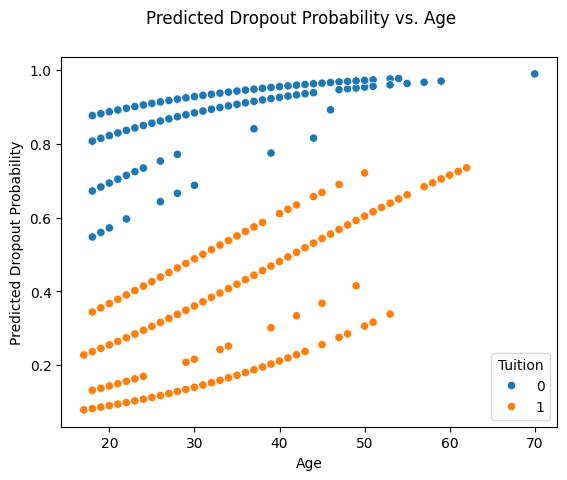

In [ ]:
#3.
y_reg = reg.predict_proba(X)
y_reg = [row[1] for row in y_reg] #take probability
df["Dropout_Probability"] = y_reg

sns.scatterplot(y=df["Dropout_Probability"], x= df["Age"], hue=df["Tuition"])
plt.suptitle("Predicted Dropout Probability vs. Age")
plt.xlabel("Age")
plt.ylabel("Predicted Dropout Probability")
plt.show()

In [ ]:
average_up_to_date = df[df['Tuition'] == 1]['Dropout_Probability'].mean()
average_not_up_to_date = df[df['Tuition'] == 0]['Dropout_Probability'].mean()

difference = average_not_up_to_date - average_up_to_date
print(difference)

0.6181006153586197


Being up to date on tuition seems to reduce the dropout probability the most for younger ages, where the gap between dropout probability is greatest with being up do date and not up to date on tuition. This gap decreases as age increases. Finally, from taking the average predicted probability of dropping out for both being up to date and not on tuition, being up to date on tuition decreases the predicted probability of dropout by .618.

In [ ]:
#4.

y_class = pd.Series(reg.predict(X) )

tab = pd.crosstab( y_class, df['Target1'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Target1     0    1
row_0             
0        2841  891
1         162  530

Accuracy: 0.7619801084990958


The accuracy of my classifier is .762.

In [ ]:
#5.

from sklearn.linear_model import LinearRegression

y_linear = df['Target1']
X_linear = df[['Debtor', 'Tuition', 'Scholarship', 'Age']]

model = LinearRegression().fit(X_linear, y_linear)

y_linear_pred = model.predict(X_linear)

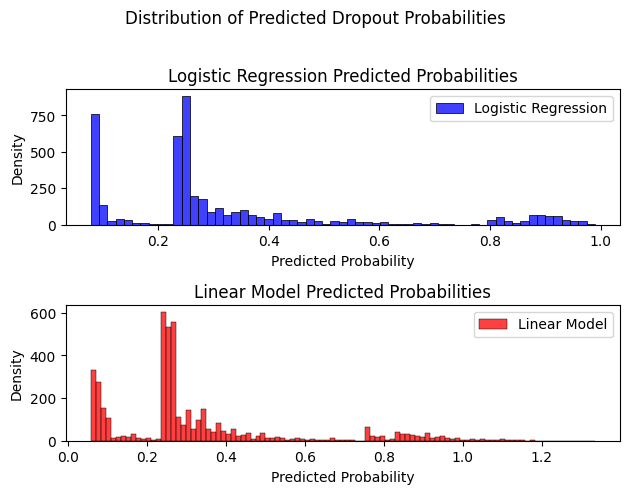

In [ ]:
fig, axes = plt.subplots(2, 1)

sns.histplot(df['Dropout_Probability'], color='blue', label='Logistic Regression', ax=axes[0])
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.histplot(y_linear_pred, color='red', label='Linear Model', ax=axes[1])
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Distribution of Predicted Dropout Probabilities', y=1.02)
plt.tight_layout()
plt.show()

Both the logistic regression and linear model create similar histograms of the predicted probabilities, with two peaks around .1 and .25, and are right-skewed. However, the linear model has a much larger spread, and goes above the predicted probability of 1, while the logistic regression model ranges only from 0 to 1.

6. Based on my above work, the students that are the most at-risk of dropping out are not being up to date on tuition and being older. Some interventions that could help target these at-risk students and keep them enrolled is more support systems for older students, and programs to help students stay up-to-date on their tuition, especially for older students who are more likely to drop out in general.

In [ ]:
#7.

y = df['Target']
X = df[['Debtor', 'Tuition', 'Units']]

mnl = LogisticRegression(penalty=None).fit(X,y)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print('Coefficients for each target:')
mnl_coef

Coefficients for each target:


,Debtor,Tuition,Units
0,0.364253,-1.782824,-0.289422
1,0.279227,0.207343,-0.025537
2,-0.643480,1.575481,0.314959


In [ ]:
pd.crosstab(y, mnl.predict(X))

col_0,Dropout,Graduate
Target,,
Dropout,1054,367
Enrolled,280,514
Graduate,146,2063


The hard classification was able to largely accurately preduct both dropouts and graduates, most accurately with graduates. However, it was not able to predict any enrolled students, and most commonly predicts enrolled students as graduates.

In [ ]:
y_proba = mnl.predict_proba(X)

proba_df = pd.DataFrame(y_proba, columns=[f"Prob_{c}" for c in mnl.classes_])
display(proba_df.head())

,Prob_Dropout,Prob_Enrolled,Prob_Graduate
0,0.680560,0.210486,0.108954
1,0.706615,0.145494,0.147892
2,0.954343,0.040341,0.005316
3,0.117346,0.176786,0.705867
4,0.183691,0.212551,0.603758


While the hard classifications do not predict whether a student is enrolled, the predicted probabilities do and predict every class, while the probability of being enrolled is the lowest.

##3.

In [ ]:
#1.

df = pd.read_csv('cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [ ]:
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
print(df.isna().sum())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


There are 106 missing values for the drug columns, so I am removing those values.

In [ ]:
df.dropna(inplace=True)
print(df.isna().sum())

Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


In [ ]:
df["Status"] = df["Status"].apply(lambda x: 0 if x == "D" else 1)
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,0
1,1.1,N,D-penicillamine,3.0,1
2,1.4,S,D-penicillamine,4.0,0
3,1.8,S,D-penicillamine,4.0,0
4,3.4,N,Placebo,3.0,1


In [ ]:
df["Drug"] = df["Drug"].apply(lambda x: 0 if x == "Placebo" else 1)
X_edema = pd.get_dummies(df['Edema'], drop_first=True)
df = pd.concat([df, X_edema], axis=1)
df.head()

,Bilirubin,Edema,Drug,Stage,Status,S,Y
0,14.5,Y,1,4.0,0,False,True
1,1.1,N,1,3.0,1,False,False
2,1.4,S,1,4.0,0,True,False
3,1.8,S,1,4.0,0,True,False
4,3.4,N,0,3.0,1,False,False


In [ ]:
#2.

from sklearn.linear_model import LogisticRegression

y = df["Status"]
X = df[["Drug", "Bilirubin", "S", "Y"]]

reg = LogisticRegression(penalty = None, max_iter=5000)
reg = reg.fit(X, y)

pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Drug,-0.252830
1,Bilirubin,-0.350387
2,S,-0.578232
3,Y,-2.859220


The drug does not appear to improve survival probability given that it has a negative coefficient. Having higher billirubin predicts a lower survival rate, with a negative coefficient of -.35. Survival probability also decreases with edema, with a lower coefficient for edema despite dirutics of -2.85 than for resolvable with dirutics with a coefficeint of -.578.

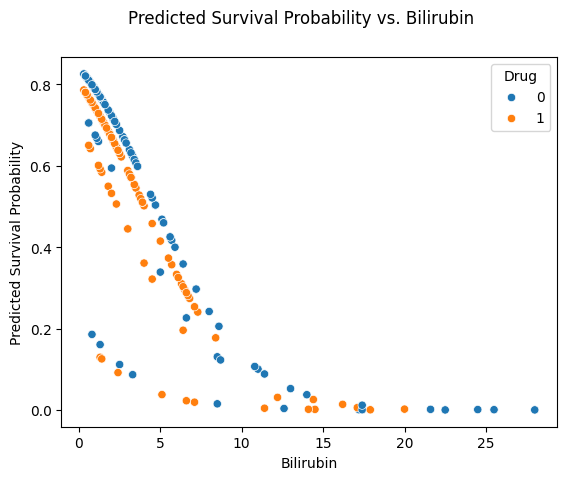

In [ ]:
#3.
y_reg = reg.predict_proba(X)
y_reg = [row[1] for row in y_reg] #take probability
df["Survival_Probability"] = y_reg

sns.scatterplot(y=df["Survival_Probability"], x= df["Bilirubin"], hue=df["Drug"])
plt.suptitle("Predicted Survival Probability vs. Bilirubin")
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.show()

In [ ]:
drug = df[df['Drug'] == 1]['Survival_Probability'].mean()
no_drug = df[df['Drug'] == 0]['Survival_Probability'].mean()

difference = drug - no_drug
print(difference)

-0.02180595611354208


Lower levels of Bilirubin seems to increase the patient survival rate, while an increase in Bilirubin seems to decrease survival rate dramatically. On average, patients who take the drug decrease their survival probability by about .022.

In [ ]:
#4.
y_class = pd.Series(reg.predict(X) )

tab = pd.crosstab( y_class, df['Status'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Status   0    1
row_0          
0       57   14
1       68  173

Accuracy: 0.7371794871794872


The accuracy of the model is .737.

In [ ]:
#5.
y_linear = df['Status']
X_linear = df[["Drug", "Bilirubin", "S", "Y"]]

model = LinearRegression().fit(X_linear, y_linear)

y_linear_pred = model.predict(X_linear)

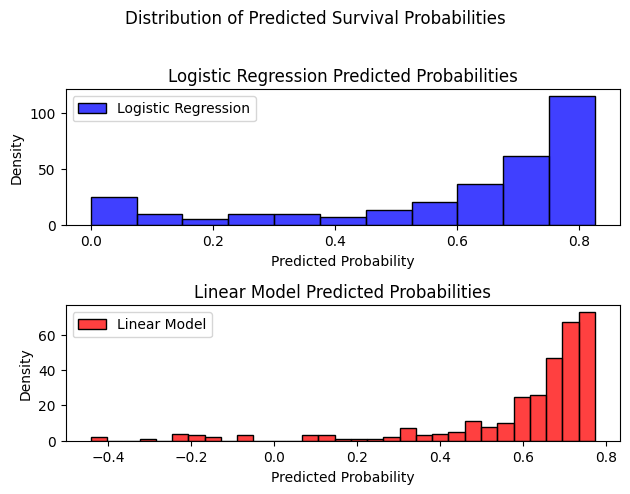

In [ ]:
fig, axes = plt.subplots(2, 1)

sns.histplot(df['Survival_Probability'], color='blue', label='Logistic Regression', ax=axes[0])
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.histplot(y_linear_pred, color='red', label='Linear Model', ax=axes[1])
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Distribution of Predicted Survival Probabilities', y=1.02)
plt.tight_layout()
plt.show()

Overall, the distributions of the logistic regression and linear models look similar and are left-skewed. However, the linear model is slightly more left-skewed and also has predicted probabilities that range from -.4 to .8, while the logistic regression model only spans from 0 to .8.

In [ ]:
#6.
y = df['Stage']
X = df[["S", "Y", "Bilirubin"]]

mnl = LogisticRegression(penalty=None).fit(X,y)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print('Coefficients for each target:')
mnl_coef

Coefficients for each target:


,S,Y,Bilirubin
0,-9.386383,-4.528670,-0.442467
1,2.756761,0.759798,0.083879
2,3.115884,1.034721,0.156874
3,3.513738,2.734151,0.201714


In [ ]:
pd.crosstab(y, mnl.predict(X))

col_0,3.0,4.0
Stage,,
1.0,16,0
2.0,61,6
3.0,102,18
4.0,74,35


The hard classification predicts oly classes 3 and 4, mostly predicting class 3. It is able to largely predict most of the stage 3 values, while it is largely inaccurate at predicting the other classes. Even though it does predict stage 4, only 35 of these predictions were accurate, while 74 were not. It also does not predict stage 1 or 2 at all.

In [ ]:
y_proba = mnl.predict_proba(X)

proba_df = pd.DataFrame(y_proba, columns=[f"Prob_{c}" for c in mnl.classes_])
display(proba_df.head())

,Prob_1.0,Prob_2.0,Prob_3.0,Prob_4.0
0,2.965087e-08,0.022548,0.124085,0.853367
1,7.611338e-02,0.252747,0.397286,0.273854
2,2.404877e-07,0.175628,0.404099,0.420273
3,1.887425e-07,0.170140,0.403070,0.426790
4,2.053816e-02,0.228845,0.425472,0.325145


The predicted probabilities do predict every class, although the probabilities of stages 1 and 2 are the lowest, while the hard classification only predicts stages 3 and 4.

##4.

The coefficients of a logistic regression show how a predictor affects the log-odds of an outcome. So, a 1-unit increase in x increases the log-odds of the outcome by the coefficient when all other variables are held constant. If you exponentiate the coefficient, it will also give the odds ratio.

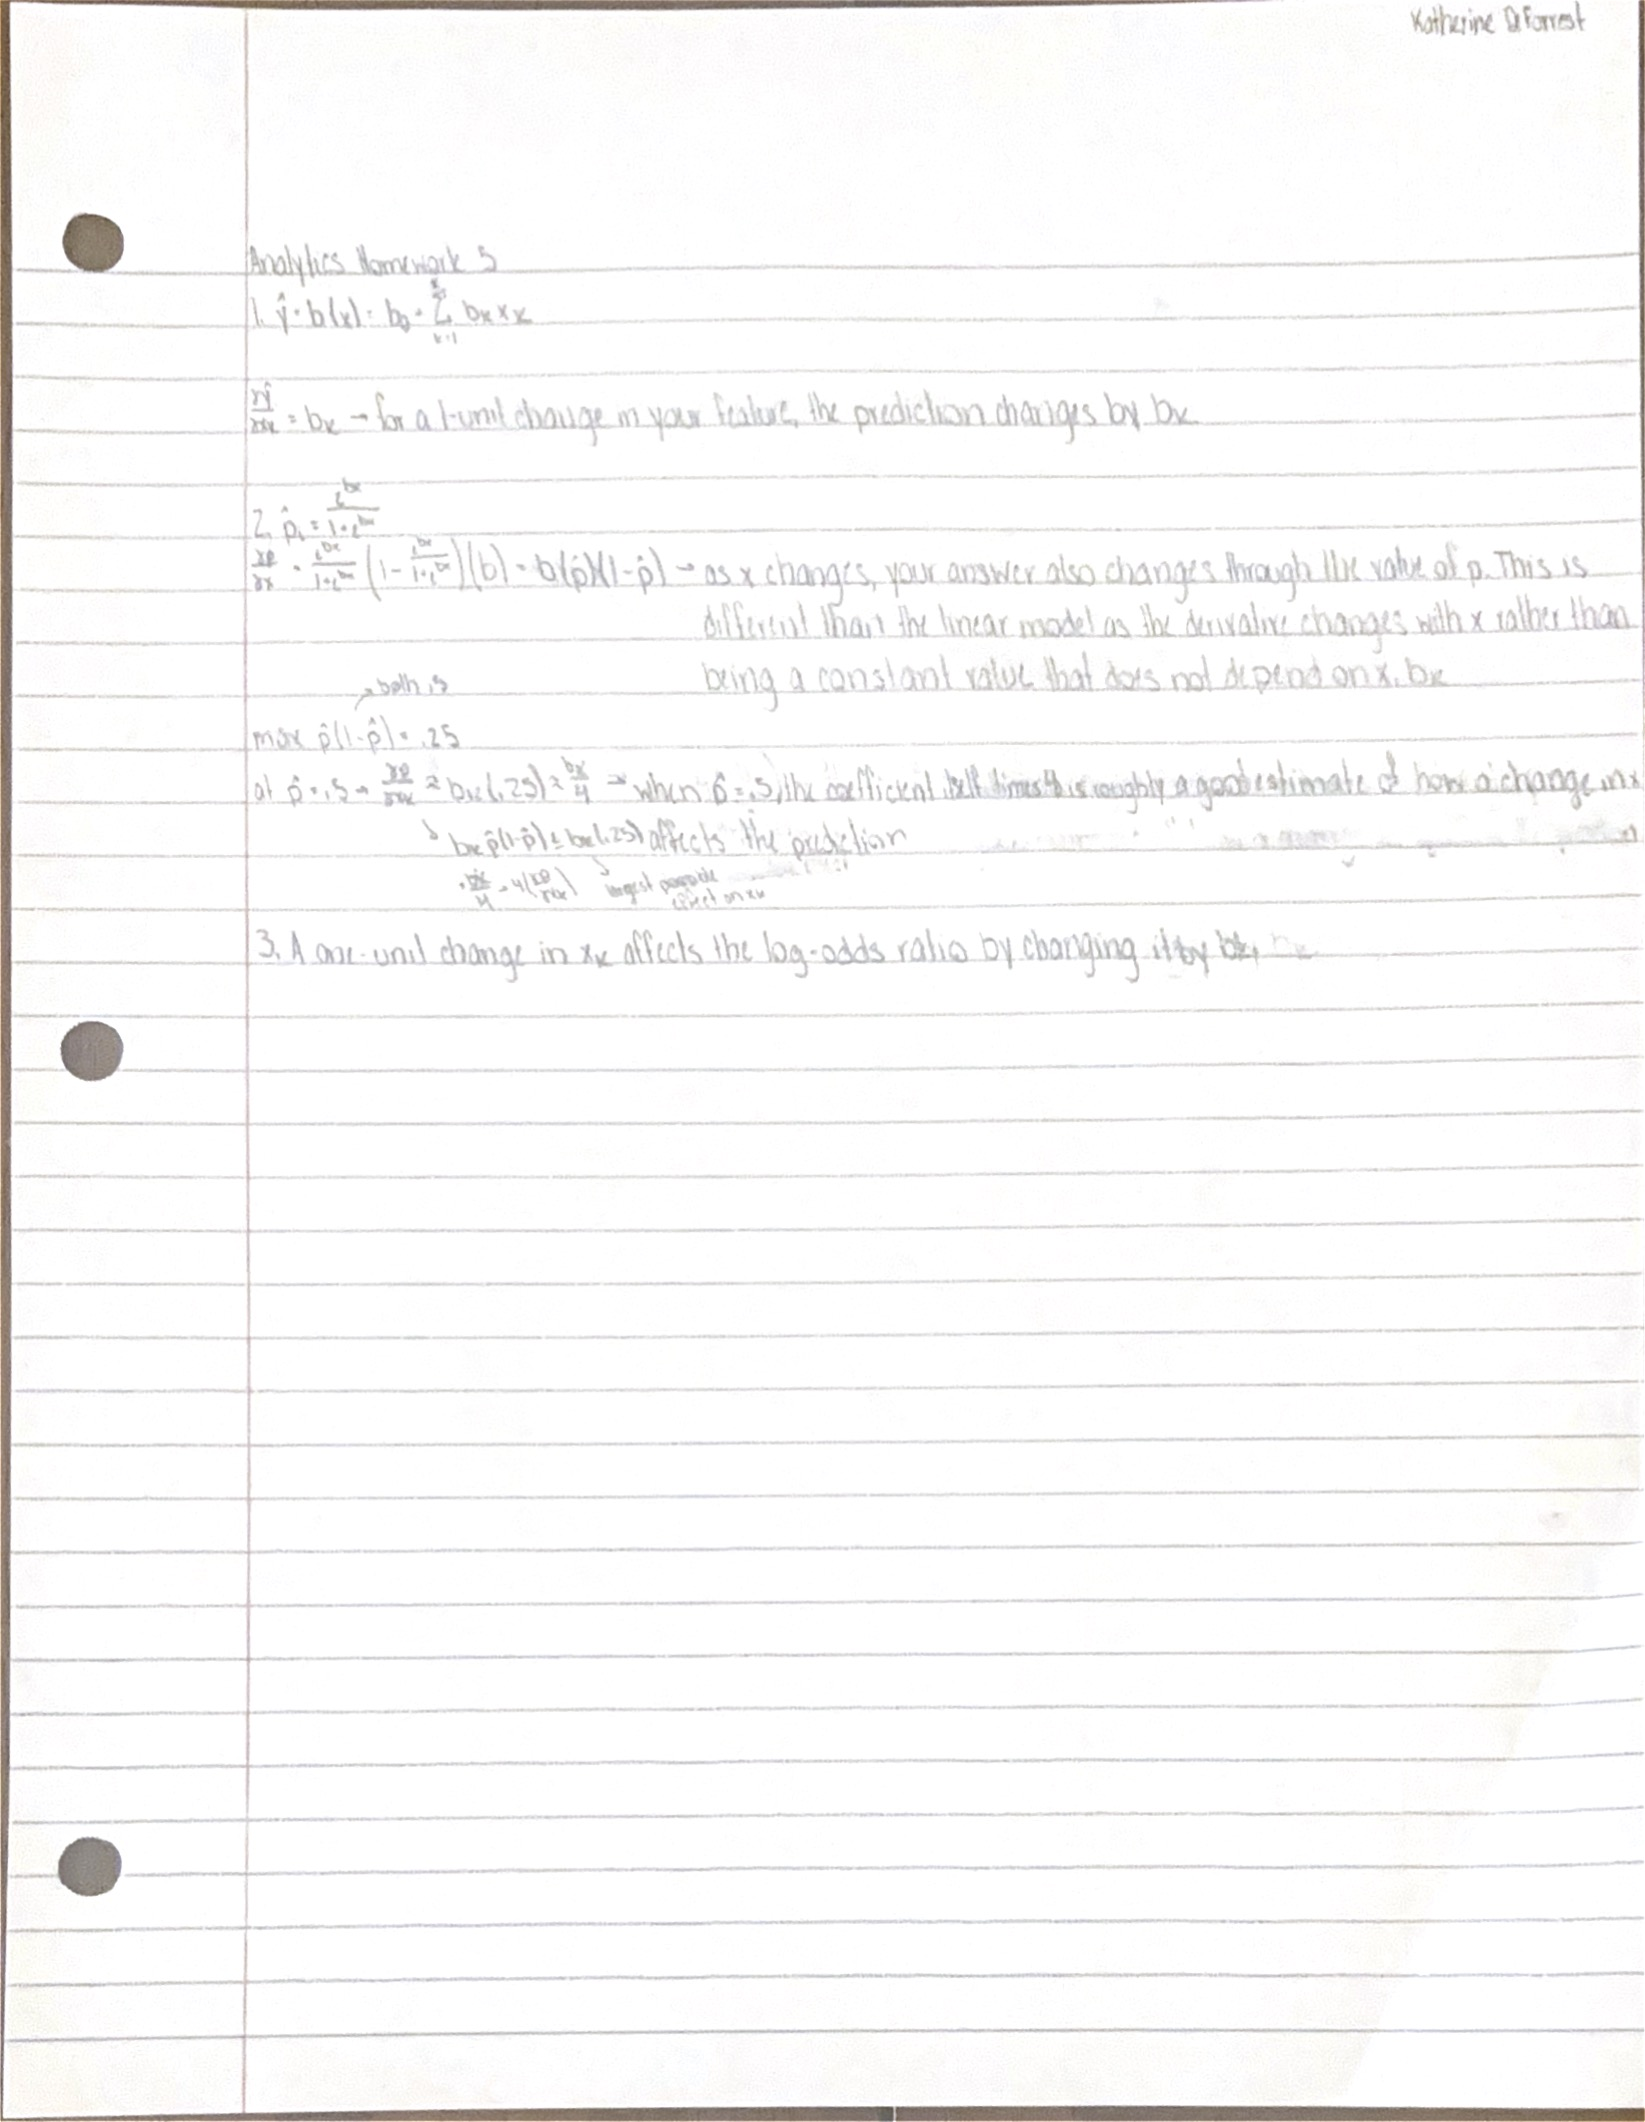